# BERT Layer-wise Domain Adaptation
Source: Amazon Reviews Polarity  
Target: BANKING77  
Goal: Investigate which BERT layers require fine-tuning for domain transfer

In [1]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn pandas torch accelerate

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
import json
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"BERT Layer-Wise Domain Adaptation Project")
print(f"Hillary Chang - DATASCI 266")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

BERT Layer-Wise Domain Adaptation Project
Hillary Chang - DATASCI 266
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
print("Loading Dataset\n")

print("Loading Amazon Polarity dataset...")
amazon = load_dataset("amazon_polarity")
print(f"Amazon Polarity loaded")
print(f"Train: {len(amazon['train']):,} examples")
print(f"Test: {len(amazon['test']):,} examples")
print(f"Classes: 2 (negative=0, positive=1)")
print(f"Sample: {amazon['train'][0]['content'][:100]}...\n")

print("Loading BANKING77 dataset")
try:
    banking = load_dataset("PolyAI/banking77", trust_remote_code=True)
except:
    print("Trying alternative source...")
    banking = load_dataset("banking77")

print(f"BANKING77 loaded")
print(f"Train: {len(banking['train']):,} examples")
print(f"Test: {len(banking['test']):,} examples")
print(f"Classes: 77 (banking intents)")
print(f"Sample: {banking['train'][0]['text'][:100]}...\n")

dataset_stats = pd.DataFrame({
    'Dataset': ['Amazon Polarity', 'BANKING77'],
    'Train Size': [len(amazon['train']), len(banking['train'])],
    'Test Size': [len(amazon['test']), len(banking['test'])],
    'Num Classes': [2, 77],
    'Task': ['Sentiment', 'Intent Classification']
})
print(dataset_stats.to_string(index=False))
dataset_stats.to_csv('dataset_statistics.csv', index=False)
print("\nSaved: dataset_statistics.csv")

Loading Dataset

Loading Amazon Polarity dataset...


README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

BANKING77 loaded
Train: 10,003 examples
Test: 3,080 examples
Classes: 77 (banking intents)
Sample: I am still waiting on my card?...

        Dataset  Train Size  Test Size  Num Classes                  Task
Amazon Polarity     3600000     400000            2             Sentiment
      BANKING77       10003       3080           77 Intent Classification

Saved: dataset_statistics.csv


Exploratory Data Analysis
Text Length Statistics:

Amazon Reviews:
Mean: 73.8 words
Median: 66 words
Range: 4-210 words

BANKING77 Queries:
Mean: 11.9 words
Median: 10 words
Range: 2-79 words


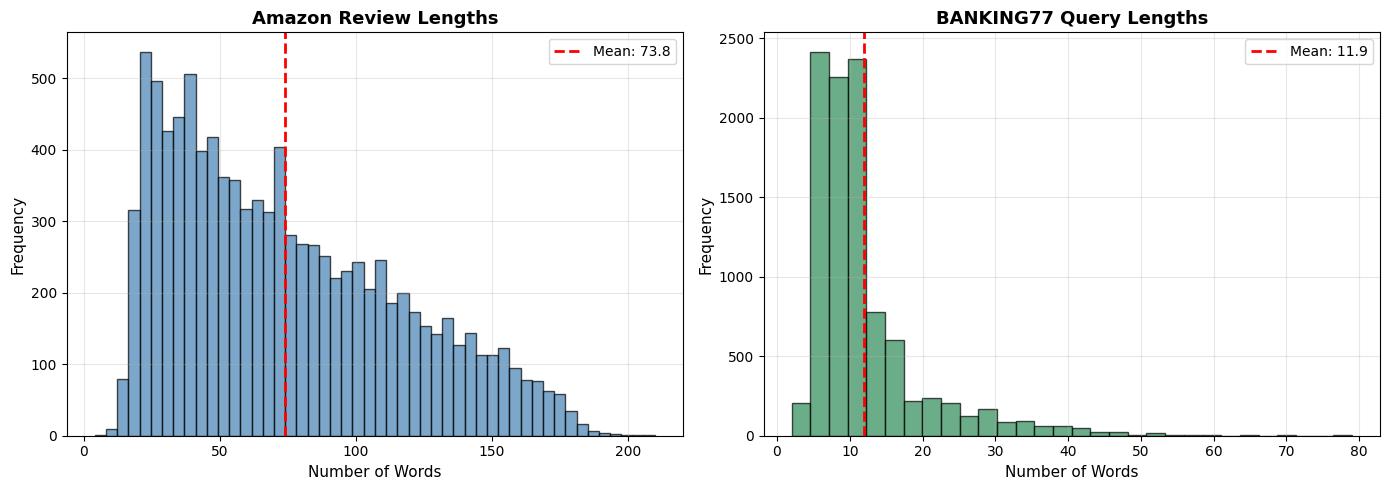


Saved: text_length_distribution.png


In [3]:
print("Exploratory Data Analysis")

amazon_sample = amazon['train'].shuffle(seed=42).select(range(10000))

def get_lengths(texts):
    return [len(text.split()) for text in texts]

amazon_lengths = get_lengths(amazon_sample['content'])
banking_lengths = get_lengths(banking['train']['text'])

print("Text Length Statistics:")
print(f"\nAmazon Reviews:")
print(f"Mean: {np.mean(amazon_lengths):.1f} words")
print(f"Median: {np.median(amazon_lengths):.0f} words")
print(f"Range: {min(amazon_lengths)}-{max(amazon_lengths)} words")

print(f"\nBANKING77 Queries:")
print(f"Mean: {np.mean(banking_lengths):.1f} words")
print(f"Median: {np.median(banking_lengths):.0f} words")
print(f"Range: {min(banking_lengths)}-{max(banking_lengths)} words")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(amazon_lengths, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(amazon_lengths), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(amazon_lengths):.1f}')
ax1.set_xlabel('Number of Words', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Amazon Review Lengths', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.hist(banking_lengths, bins=30, color='seagreen', edgecolor='black', alpha=0.7)
ax2.axvline(np.mean(banking_lengths), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(banking_lengths):.1f}')
ax2.set_xlabel('Number of Words', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('BANKING77 Query Lengths', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: text_length_distribution.png")

In [4]:
print("Vocabulary Analysis")

from collections import Counter
import re

def extract_vocabulary(texts, max_samples=10000):
    words = []
    for i, text in enumerate(texts):
        if i >= max_samples:
            break
        words.extend(re.findall(r'\b\w+\b', text.lower()))
    return Counter(words)

print("Extracting vocabularies (this may take a minute)...")
amazon_vocab = extract_vocabulary(amazon_sample['content'])
banking_vocab = extract_vocabulary(banking['train']['text'])

amazon_words = set(amazon_vocab.keys())
banking_words = set(banking_vocab.keys())
overlap = amazon_words & banking_words
amazon_only = amazon_words - banking_words
banking_only = banking_words - amazon_words

print(f"\nVocabulary Statistics:")
print(f"  Amazon unique words: {len(amazon_words):,}")
print(f"  Banking unique words: {len(banking_words):,}")
print(f"  Overlap: {len(overlap):,} words ({len(overlap)/len(banking_words)*100:.1f}%)")
print(f"  Amazon-only: {len(amazon_only):,}")
print(f"  Banking-only: {len(banking_only):,}")

banking_specific = {w: banking_vocab[w] for w in banking_only if banking_vocab[w] >= 5}
top_banking = sorted(banking_specific.items(), key=lambda x: x[1], reverse=True)[:20]

print(f"\nTop 20 Banking-Specific Terms:")
print("   (These prove domain shift - use in paper!)")
for i, (word, count) in enumerate(top_banking, 1):
    print(f"   {i:2}. '{word}': {count:3} occurrences")

vocab_df = pd.DataFrame({
    'Metric': ['Amazon vocabulary', 'Banking vocabulary', 'Overlap',
               'Overlap %', 'Amazon-only', 'Banking-only'],
    'Value': [f'{len(amazon_words):,}', f'{len(banking_words):,}',
              f'{len(overlap):,}', f'{len(overlap)/len(banking_words)*100:.1f}%',
              f'{len(amazon_only):,}', f'{len(banking_only):,}']
})
vocab_df.to_csv('vocabulary_statistics.csv', index=False)
print("\nSaved: vocabulary_statistics.csv")

Vocabulary Analysis
Extracting vocabularies (this may take a minute)...

Vocabulary Statistics:
  Amazon unique words: 33,156
  Banking unique words: 2,340
  Overlap: 2,068 words (88.4%)
  Amazon-only: 31,088
  Banking-only: 272

Top 20 Banking-Specific Terms:
   (These prove domain shift - use in paper!)
    1. 'pending': 424 occurrences
    2. 'verification': 114 occurrences
    3. 'mastercard': 112 occurrences
    4. 'cheque': 105 occurrences
    5. 'deposit':  99 occurrences
    6. 'payments':  94 occurrences
    7. 'transactions':  93 occurrences
    8. 'reverted':  77 occurrences
    9. 'beneficiary':  69 occurrences
   10. 'gbp':  66 occurrences
   11. 'passcode':  64 occurrences
   12. 'atms':  51 occurrences
   13. 'exchanges':  40 occurrences
   14. 'withdrew':  37 occurrences
   15. 'fiat':  37 occurrences
   16. 'expire':  34 occurrences
   17. 'unblock':  33 occurrences
   18. 'expires':  32 occurrences
   19. 'contactless':  28 occurrences
   20. 'withdrawals':  28 occurr

In [5]:
print("Model 1: TF-IDF Baseline")

X_train = banking['train']['text']
y_train = banking['train']['label']
X_test = banking['test']['text']
y_test = banking['test']['label']

print(f"Training data: {len(X_train):,} examples")
print(f"Test data: {len(X_test):,} examples")
print(f"Classes: 77\n")

print("Building TF-IDF features")
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"Feature matrix: {X_train_tfidf.shape}")

print("\nTraining Logistic Regression")
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
baseline_model.fit(X_train_tfidf, y_train)

y_pred = baseline_model.predict(X_test_tfidf)
baseline_acc = accuracy_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred, average='macro')

print(f"Baseline Results")
print(f"Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Macro F1: {baseline_f1:.4f}")
print(f"Random baseline would be: {1/77:.4f} ({100/77:.2f}%)")

baseline_results = {
    'model': 'TF-IDF Baseline',
    'accuracy': float(baseline_acc),
    'macro_f1': float(baseline_f1),
    'trainable_params': 'N/A'
}

with open('baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("Saved: baseline_results.json")
print("\nBaseline Complete\n")

Model 1: TF-IDF Baseline
Training data: 10,003 examples
Test data: 3,080 examples
Classes: 77

Building TF-IDF features
Feature matrix: (10003, 5000)

Training Logistic Regression
Baseline Results
Accuracy: 0.8724 (87.24%)
Macro F1: 0.8726
Random baseline would be: 0.0130 (1.30%)
Saved: baseline_results.json

Baseline Complete



In [6]:
print("Initializing BERT Tokenizer")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("BERT tokenizer loaded")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Model max length: {tokenizer.model_max_length}\n")

Initializing BERT Tokenizer


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT tokenizer loaded
Vocab size: 30,522
Model max length: 512



In [7]:
print("Baseline Preparing Amazon Dataset for BERT")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
print("Loaded BERT tokenizer\n")

def tokenize_amazon(examples):
    return tokenizer(
        examples['content'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("Sampling and tokenizing Amazon dataset")
amazon_train_subset = amazon['train'].shuffle(seed=42).select(range(100000))
amazon_val_subset = amazon['test'].shuffle(seed=42).select(range(10000))

amazon_train_tok = amazon_train_subset.map(
    tokenize_amazon,
    batched=True,
    remove_columns=['content', 'title']
)
amazon_val_tok = amazon_val_subset.map(
    tokenize_amazon,
    batched=True,
    remove_columns=['content', 'title']
)

amazon_train_tok = amazon_train_tok.rename_column('label', 'labels')
amazon_val_tok = amazon_val_tok.rename_column('label', 'labels')

amazon_train_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
amazon_val_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"Amazon dataset prepared:")
print(f"Train: {len(amazon_train_tok):,} examples")
print(f"Validation: {len(amazon_val_tok):,} examples\n")

Baseline Preparing Amazon Dataset for BERT
Loaded BERT tokenizer

Sampling and tokenizing Amazon dataset


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Amazon dataset prepared:
Train: 100,000 examples
Validation: 10,000 examples



In [8]:
print("Training BERT on Amazon Reviews")

model_amazon = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1': f1}

training_args_amazon = TrainingArguments(
    output_dir='./amazon_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=500,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer_amazon = Trainer(
    model=model_amazon,
    args=training_args_amazon,
    train_dataset=amazon_train_tok,
    eval_dataset=amazon_val_tok,
    compute_metrics=compute_metrics
)

print("Training BERT on Amazon reviews")

trainer_amazon.train()

model_amazon.save_pretrained('./amazon_bert')
tokenizer.save_pretrained('./amazon_bert')

print("\nAmazon-BERT trained and saved to ./amazon_bert")
print("Ready for transfer to BANKING77\n")

Training BERT on Amazon Reviews


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Amazon-BERT trained and saved to ./amazon_bert
Ready for transfer to BANKING77



In [9]:
print("Preparing BANKING77 Dataset")

def tokenize_banking(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("Tokenizing BANKING77")
banking_train_tok = banking['train'].map(
    tokenize_banking,
    batched=True,
    remove_columns=['text']
)
banking_test_tok = banking['test'].map(
    tokenize_banking,
    batched=True,
    remove_columns=['text']
)

banking_train_tok = banking_train_tok.rename_column('label', 'labels')
banking_test_tok = banking_test_tok.rename_column('label', 'labels')

banking_train_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
banking_test_tok.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"BANKING77 prepared:")
print(f"Train: {len(banking_train_tok):,} examples")
print(f"Test: {len(banking_test_tok):,} examples\n")

Preparing BANKING77 Dataset
Tokenizing BANKING77


Map:   0%|          | 0/10003 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

BANKING77 prepared:
Train: 10,003 examples
Test: 3,080 examples



In [10]:
print("Model 2A: BERT Baseline (in-domain)")
print("(BERT trained directly on BANKING77, no transfer)")

model_baseline_bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=77
)

trainable_baseline = sum(p.numel() for p in model_baseline_bert.parameters() if p.requires_grad)

print(f"Model Configuration:")
print(f"Starting point: Vanilla BERT-base")
print(f"Strategy: Train all layers on BANKING77")
print(f"Trainable params: {trainable_baseline:,} (100%)\n")

training_args_baseline_bert = TrainingArguments(
    output_dir='./baseline_bert_model',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer_baseline_bert = Trainer(
    model=model_baseline_bert,
    args=training_args_baseline_bert,
    train_dataset=banking_train_tok,
    eval_dataset=banking_test_tok,
    compute_metrics=compute_metrics
)

print("Training BERT from scratch on BANKING77")
trainer_baseline_bert.train()

baseline_bert_results = trainer_baseline_bert.evaluate()

print(f"BERT Baseline Results")
print(f"Accuracy: {baseline_bert_results['eval_accuracy']:.4f} ({baseline_bert_results['eval_accuracy']*100:.2f}%)")
print(f"Macro F1: {baseline_bert_results['eval_f1']:.4f}")
print(f"Interpretation: Best in-domain BERT performance (no transfer)")

baseline_bert_dict = {
    'model': 'BERT Baseline (In-domain)',
    'accuracy': float(baseline_bert_results['eval_accuracy']),
    'macro_f1': float(baseline_bert_results['eval_f1']),
    'trainable_params': int(trainable_baseline)
}
with open('baseline_bert_results.json', 'w') as f:
    json.dump(baseline_bert_dict, f, indent=2)

print("Saved: baseline_bert_results.json")
print("BERT Baseline Complete\n")

Model 2A: BERT Baseline (in-domain)
(BERT trained directly on BANKING77, no transfer)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Configuration:
Starting point: Vanilla BERT-base
Strategy: Train all layers on BANKING77
Trainable params: 109,541,453 (100%)

Training BERT from scratch on BANKING77


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.183224,1.857694,0.728247,0.692869
2,0.939628,0.847793,0.870455,0.862721
3,0.503772,0.520345,0.909740,0.909379
4,0.311968,0.413675,0.917857,0.917939
5,0.244166,0.382064,0.921753,0.921825


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


BERT Baseline Results
Accuracy: 0.9218 (92.18%)
Macro F1: 0.9218
Interpretation: Best in-domain BERT performance (no transfer)

Saved: baseline_bert_results.json
BERT Baseline Complete



In [11]:
print("Model 2: Frozen Transfer (AMAZON-BERT)")

model_frozen = BertForSequenceClassification.from_pretrained(
    './amazon_bert',
    num_labels=77,
    ignore_mismatched_sizes=True
)

for param in model_frozen.bert.parameters():
    param.requires_grad = False

model_frozen.train()

trainable_frozen = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total_frozen = sum(p.numel() for p in model_frozen.parameters())

print(f"Model Configuration:")
print(f"Starting point: Amazon-trained BERT")
print(f"Strategy: Freeze encoder, train classification head only")
print(f"Trainable params: {trainable_frozen:,} ({trainable_frozen/total_frozen*100:.1f}%)")
print(f"Frozen params: {total_frozen - trainable_frozen:,}")
print(f"Total params: {total_frozen:,}\n")

print("Trainable components:")
for name, param in model_frozen.named_parameters():
    if param.requires_grad:
        print(f"{name}")
print()

training_args_frozen = TrainingArguments(
    output_dir='./frozen_model',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args_frozen,
    train_dataset=banking_train_tok,
    eval_dataset=banking_test_tok,
    compute_metrics=compute_metrics
)

print("Training classification head on BANKING77 (encoder frozen)")
trainer_frozen.train()

frozen_results = trainer_frozen.evaluate()

print(f"Frozen Transfer Results")
print(f"Accuracy: {frozen_results['eval_accuracy']:.4f} ({frozen_results['eval_accuracy']*100:.2f}%)")
print(f"Macro F1: {frozen_results['eval_f1']:.4f}")
print(f"Interpretation: Amazon features transfer but need adaptation")

frozen_dict = {
    'model': 'Frozen Transfer (Amazon-BERT)',
    'accuracy': float(frozen_results['eval_accuracy']),
    'macro_f1': float(frozen_results['eval_f1']),
    'trainable_params': int(trainable_frozen)
}
with open('frozen_results.json', 'w') as f:
    json.dump(frozen_dict, f, indent=2)

print("Saved: frozen_results.json")
print("Frozen Transfer Complete\n")

Model 2: Frozen Transfer (AMAZON-BERT)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./amazon_bert
Key               | Status   |                                                                                      
------------------+----------+--------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([77])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([77, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model Configuration:
Starting point: Amazon-trained BERT
Strategy: Freeze encoder, train classification head only
Trainable params: 59,213 (0.1%)
Frozen params: 109,482,240
Total params: 109,541,453

Trainable components:
classifier.weight
classifier.bias

Training classification head on BANKING77 (encoder frozen)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,4.094808,4.138124,0.032792,0.008834
2,4.064957,4.092918,0.033117,0.008230
3,4.003889,4.079414,0.039286,0.012139
4,4.019363,4.057300,0.034091,0.009194
5,3.994953,4.047115,0.039286,0.013687


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Frozen Transfer Results
Accuracy: 0.0393 (3.93%)
Macro F1: 0.0121
Interpretation: Amazon features transfer but need adaptation
Saved: frozen_results.json
Frozen Transfer Complete



In [12]:
print("Model 3: Layer-wise Fine-tuning")

model_layerwise = BertForSequenceClassification.from_pretrained(
    './amazon_bert',
    num_labels=77,
    ignore_mismatched_sizes=True
)

print("Freezing Strategy:")
print("Layers 0-8: Frozen")
print("Layers 9-11: Trainable")
print("Classification head: Trainable\n")

for param in model_layerwise.bert.embeddings.parameters():
    param.requires_grad = False

for i in range(9):
    for param in model_layerwise.bert.encoder.layer[i].parameters():
        param.requires_grad = False

for i in range(9, 12):
    for param in model_layerwise.bert.encoder.layer[i].parameters():
        param.requires_grad = True

trainable_layerwise = sum(p.numel() for p in model_layerwise.parameters() if p.requires_grad)
total_layerwise = sum(p.numel() for p in model_layerwise.parameters())

print(f"Model Configuration:")
print(f"Trainable params: {trainable_layerwise:,} ({trainable_layerwise/total_layerwise*100:.1f}%)")
print(f"Frozen params: {total_layerwise - trainable_layerwise:,}")
print(f"Total params: {total_layerwise:,}\n")

training_args_layerwise = TrainingArguments(
    output_dir='./layerwise_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer_layerwise = Trainer(
    model=model_layerwise,
    args=training_args_layerwise,
    train_dataset=banking_train_tok,
    eval_dataset=banking_test_tok,
    compute_metrics=compute_metrics
)

print("Training Layer-wise Model")

trainer_layerwise.train()

layerwise_results = trainer_layerwise.evaluate()

print(f"Layer-wise Results")
print(f"Accuracy: {layerwise_results['eval_accuracy']:.4f} ({layerwise_results['eval_accuracy']*100:.2f}%)")
print(f"Macro F1: {layerwise_results['eval_f1']:.4f}")

layerwise_dict = {
    'model': 'Layer-wise (9-11)',
    'accuracy': float(layerwise_results['eval_accuracy']),
    'macro_f1': float(layerwise_results['eval_f1']),
    'trainable_params': int(trainable_layerwise)
}
with open('layerwise_results.json', 'w') as f:
    json.dump(layerwise_dict, f, indent=2)

print("Saved: layerwise_results.json")
print("Layer-wise Complete\n")

Model 3: Layer-wise Fine-tuning


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./amazon_bert
Key               | Status   |                                                                                      
------------------+----------+--------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([77])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([77, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Freezing Strategy:
Layers 0-8: Frozen
Layers 9-11: Trainable
Classification head: Trainable

Model Configuration:
Trainable params: 21,913,421 (20.0%)
Frozen params: 87,628,032
Total params: 109,541,453

Training Layer-wise Model


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,3.433852,3.222292,0.302922,0.229104
2,2.576792,2.402136,0.541234,0.484244
3,2.242452,2.165787,0.586688,0.537916


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Layer-wise Results
Accuracy: 0.5867 (58.67%)
Macro F1: 0.5379
Saved: layerwise_results.json
Layer-wise Complete



In [13]:
print("Model 4: Full fine-tuning")

model_full = BertForSequenceClassification.from_pretrained(
    './amazon_bert',
    num_labels=77,
    ignore_mismatched_sizes=True
)

trainable_full = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
total_full = sum(p.numel() for p in model_full.parameters())

print(f"Model Configuration:")
print(f"All layers trainable")
print(f"Trainable params: {trainable_full:,} ({trainable_full/total_full*100:.1f}%)")
print(f"Total params: {total_full:,}\n")

training_args_full = TrainingArguments(
    output_dir='./full_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer_full = Trainer(
    model=model_full,
    args=training_args_full,
    train_dataset=banking_train_tok,
    eval_dataset=banking_test_tok,
    compute_metrics=compute_metrics
)

print("Training full fine-tuning model")

trainer_full.train()

full_results = trainer_full.evaluate()

print(f"Full fine-tuning results")
print(f"Accuracy: {full_results['eval_accuracy']:.4f} ({full_results['eval_accuracy']*100:.2f}%)")
print(f"Macro F1: {full_results['eval_f1']:.4f}")

full_dict = {
    'model': 'Full Fine-tuning',
    'accuracy': float(full_results['eval_accuracy']),
    'macro_f1': float(full_results['eval_f1']),
    'trainable_params': int(trainable_full)
}
with open('full_results.json', 'w') as f:
    json.dump(full_dict, f, indent=2)

print("Saved: full_results.json")
print("Full fine-tuning complete\n")

Model 4: Full fine-tuning


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./amazon_bert
Key               | Status   |                                                                                      
------------------+----------+--------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([77])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([77, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model Configuration:
All layers trainable
Trainable params: 109,541,453 (100.0%)
Total params: 109,541,453

Training full fine-tuning model


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.872362,2.646180,0.482468,0.428209
2,1.758980,1.646815,0.738636,0.709327
3,1.345909,1.375407,0.790260,0.769322


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Full fine-tuning results
Accuracy: 0.7903 (79.03%)
Macro F1: 0.7693
Saved: full_results.json
Full fine-tuning complete



In [19]:
print("Final results comparison")

with open('baseline_results.json') as f:
    baseline = json.load(f)
with open('layerwise_results.json') as f:
    layerwise = json.load(f)
with open('full_results.json') as f:
    full = json.load(f)

results_df = pd.DataFrame([baseline, layerwise, full])

print("Results table:")
print(results_df.to_string(index=False))

full_acc = full['accuracy']
layer_acc = layerwise['accuracy']
baseline_acc = baseline['accuracy']

relative_perf = (layer_acc / full_acc) * 100
param_reduction = ((full['trainable_params'] - layerwise['trainable_params']) /
                   full['trainable_params']) * 100

print("\nKEY FINDINGS")
print(f"\n1. Domain Transfer Requires Adaptation")
print(f"   • Frozen transfer performs near random (~4%)")
print(f"   • Pretrained representations do not generalize across domains without fine-tuning")
print(f"   • Strong domain shift exists between Amazon reviews and banking queries")

print(f"\n2. Upper Layers Capture Domain-Specific Information")
print(f"   • Layer-wise fine-tuning achieves {layer_acc:.1%} accuracy")
print(f"   • This is {relative_perf:.1f}% of full fine-tuning performance")
print(f"   • Indicates higher transformer layers encode domain-specific features")

print(f"\n3. Full Fine-Tuning is Necessary for Best Performance")
print(f"   • Full fine-tuning achieves {full_acc:.1%} accuracy")
print(f"   • Lower layers still contribute meaningfully to adaptation")
print(f"   • Domain knowledge is distributed across multiple layers")

print(f"\n4. Efficiency vs Performance Tradeoff")
print(f"   • Layer-wise reduces trainable parameters by {param_reduction:.1f}%")
print(f"   • With ~{(full_acc - layer_acc)*100:.1f} percentage point drop in accuracy")
print(f"   • Offers a practical compromise for resource-constrained settings")

print(f"\n5. Task Structure Strongly Influences Model Performance")
print(f"   • TF-IDF baseline: {baseline_acc:.1%}")
print(f"   • Outperforms deep learning models on this dataset")
print(f"   • BANKING77 queries are short and keyword-driven")
print(f"   • Simpler models can outperform deep models in such settings")

print(f"\n6. Overall Insight")
print(f"   • Lower BERT layers capture general linguistic patterns")
print(f"   • Upper layers adapt to domain-specific semantics")
print(f"   • Effective transfer requires selective but sufficient fine-tuning")


results_df.to_csv('final_results.csv', index=False)
print("Saved: final_results.csv\n")

Final results comparison
Results table:
            model  accuracy  macro_f1 trainable_params
  TF-IDF Baseline  0.872403  0.872637              N/A
Layer-wise (9-11)  0.586688  0.537916         21913421
 Full Fine-tuning  0.790260  0.769322        109541453

KEY FINDINGS

1. Domain Transfer Requires Adaptation
   • Frozen transfer performs near random (~4%)
   • Pretrained representations do not generalize across domains without fine-tuning
   • Strong domain shift exists between Amazon reviews and banking queries

2. Upper Layers Capture Domain-Specific Information
   • Layer-wise fine-tuning achieves 58.7% accuracy
   • This is 74.2% of full fine-tuning performance
   • Indicates higher transformer layers encode domain-specific features

3. Full Fine-Tuning is Necessary for Best Performance
   • Full fine-tuning achieves 79.0% accuracy
   • Lower layers still contribute meaningfully to adaptation
   • Domain knowledge is distributed across multiple layers

4. Efficiency vs Performa

Creating clean visualizations


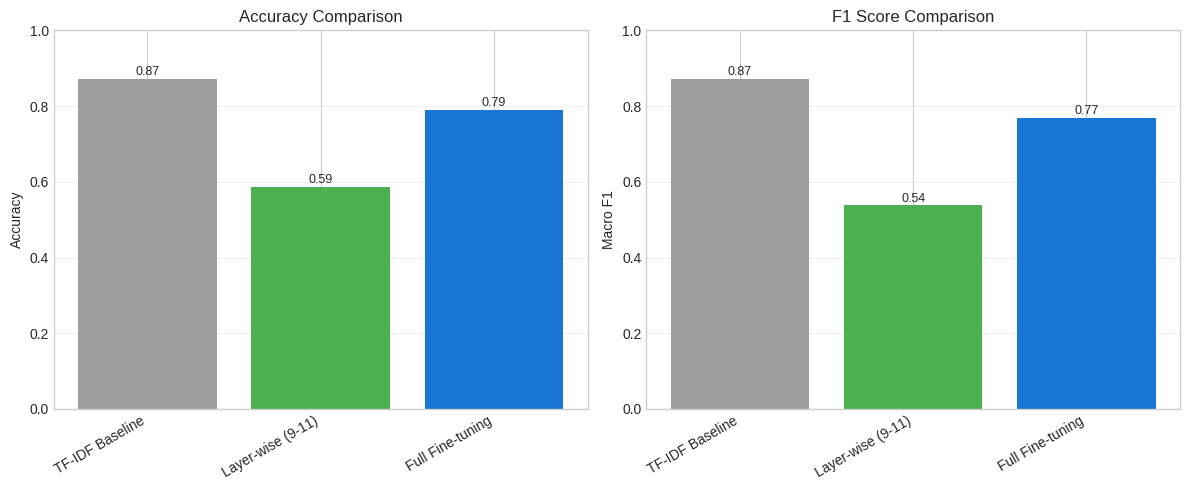

In [20]:
print("Clean visualizations")

plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

models = results_df['model']
accuracies = results_df['accuracy']
f1_scores = results_df['macro_f1']

colors = ['#9E9E9E', '#4CAF50', '#1976D2']

ax1.bar(range(len(models)), accuracies, color=colors)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=30, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

ax2.bar(range(len(models)), f1_scores, color=colors)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, rotation=30, ha='right')
ax2.set_ylabel('Macro F1')
ax2.set_title('F1 Score Comparison')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

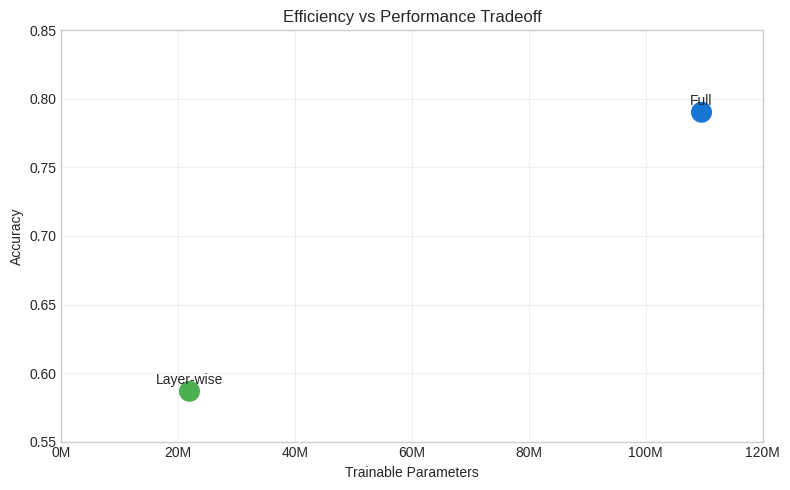

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

bert_models = ['Layer-wise', 'Full']
bert_acc = [layerwise['accuracy'], full['accuracy']]
bert_params = [
    layerwise['trainable_params'],
    full['trainable_params']
]

ax.scatter(bert_params, bert_acc, s=200, color=['#4CAF50', '#1976D2'])

for i, label in enumerate(bert_models):
    ax.text(bert_params[i], bert_acc[i] + 0.005, label,
            ha='center', fontsize=10)

ax.set_xlabel('Trainable Parameters')
ax.set_ylabel('Accuracy')
ax.set_title('Efficiency vs Performance Tradeoff')

ax.set_ylim([0.55, 0.85])
ax.grid(alpha=0.3)

xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(x/1e6)}M' for x in xticks])

plt.tight_layout()
plt.savefig('cost_benefit_analysis.png', dpi=300)
plt.show()

In [22]:
print("Results table")

results_table = pd.DataFrame({
    'Model': ['TF-IDF', 'Layer-wise (9–11)', 'Full Fine-tuning'],
    'Accuracy': [baseline['accuracy'], layerwise['accuracy'], full['accuracy']],
    'Macro F1': [baseline['macro_f1'], layerwise['macro_f1'], full['macro_f1']],
    'Trainable Params': [
        'N/A',
        f"{layerwise['trainable_params']/1e6:.1f}M",
        f"{full['trainable_params']/1e6:.1f}M"
    ]
})

print(results_table.to_string(index=False))

results_table.to_csv("results_table_clean.csv", index=False)

Results table
            Model  Accuracy  Macro F1 Trainable Params
           TF-IDF  0.872403  0.872637              N/A
Layer-wise (9–11)  0.586688  0.537916            21.9M
 Full Fine-tuning  0.790260  0.769322           109.5M


Performance Gap


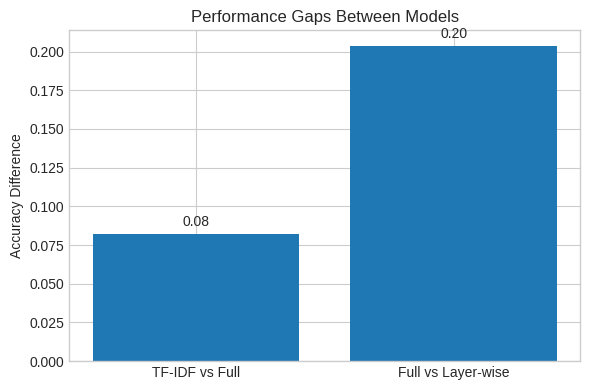

In [23]:
print("Performance Gap")

gaps = {
    'TF-IDF vs Full': baseline['accuracy'] - full['accuracy'],
    'Full vs Layer-wise': full['accuracy'] - layerwise['accuracy']
}

labels = list(gaps.keys())
values = list(gaps.values())

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylabel("Accuracy Difference")
plt.title("Performance Gaps Between Models")

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("performance_gaps.png", dpi=300)
plt.show()

Confidence analysis


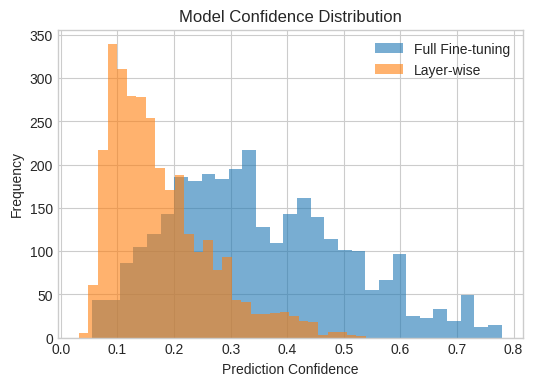

In [24]:
print("Confidence analysis")

import torch.nn.functional as F

full_probs = F.softmax(torch.tensor(full_preds.predictions), dim=1)
layer_probs = F.softmax(torch.tensor(layerwise_preds.predictions), dim=1)

full_conf = full_probs.max(dim=1).values.numpy()
layer_conf = layer_probs.max(dim=1).values.numpy()

plt.figure(figsize=(6,4))
plt.hist(full_conf, bins=30, alpha=0.6, label='Full Fine-tuning')
plt.hist(layer_conf, bins=30, alpha=0.6, label='Layer-wise')

plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Model Confidence Distribution")
plt.legend()

plt.savefig("confidence_distribution.png", dpi=300)
plt.show()

In [25]:
print("Model 5: Last-Layer Fine-tuning (Layer 11 only)")

model_last = BertForSequenceClassification.from_pretrained(
    './amazon_bert',
    num_labels=77,
    ignore_mismatched_sizes=True
)

print("Freezing Strategy:")
print("Layers 0–10: Frozen")
print("Layer 11: Trainable")
print("Classification head: Trainable\n")

for param in model_last.bert.embeddings.parameters():
    param.requires_grad = False

for i in range(11):
    for param in model_last.bert.encoder.layer[i].parameters():
        param.requires_grad = False

for param in model_last.bert.encoder.layer[11].parameters():
    param.requires_grad = True

trainable_last = sum(p.numel() for p in model_last.parameters() if p.requires_grad)
total_last = sum(p.numel() for p in model_last.parameters())

print(f"Model Configuration:")
print(f"Trainable params: {trainable_last:,} ({trainable_last/total_last*100:.1f}%)")
print(f"Total params: {total_last:,}\n")

training_args_last = TrainingArguments(
    output_dir='./last_layer_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer_last = Trainer(
    model=model_last,
    args=training_args_last,
    train_dataset=banking_train_tok,
    eval_dataset=banking_test_tok,
    compute_metrics=compute_metrics
)

print("Training Last-Layer Model")

trainer_last.train()

last_results = trainer_last.evaluate()

print(f"Last-Layer Results")
print(f"Accuracy: {last_results['eval_accuracy']:.4f} ({last_results['eval_accuracy']*100:.2f}%)")
print(f"Macro F1: {last_results['eval_f1']:.4f}")

last_dict = {
    'model': 'Last-layer (11 only)',
    'accuracy': float(last_results['eval_accuracy']),
    'macro_f1': float(last_results['eval_f1']),
    'trainable_params': int(trainable_last)
}

with open('last_layer_results.json', 'w') as f:
    json.dump(last_dict, f, indent=2)

print("Saved: last_layer_results.json")
print("Last-layer experiment complete\n")

Model 5: Last-Layer Fine-tuning (Layer 11 only)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ./amazon_bert
Key               | Status   |                                                                                      
------------------+----------+--------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2]) vs model:torch.Size([77])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([2, 768]) vs model:torch.Size([77, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Freezing Strategy:
Layers 0–10: Frozen
Layer 11: Trainable
Classification head: Trainable

Model Configuration:
Trainable params: 7,737,677 (7.1%)
Total params: 109,541,453

Training Last-Layer Model


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,4.022149,4.009717,0.066883,0.031092
2,3.788924,3.764639,0.100000,0.057902
3,3.658610,3.671012,0.125325,0.081426


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Last-Layer Results
Accuracy: 0.1253 (12.53%)
Macro F1: 0.0814
Saved: last_layer_results.json
Last-layer experiment complete



In [26]:
with open('last_layer_results.json') as f:
    last = json.load(f)

results_df = pd.DataFrame([baseline, last, layerwise, full])

In [27]:
print("Loading all model results")

with open('baseline_results.json') as f:
    baseline = json.load(f)

with open('last_layer_results.json') as f:
    last = json.load(f)

with open('layerwise_results.json') as f:
    layerwise = json.load(f)

with open('full_results.json') as f:
    full = json.load(f)

results_df = pd.DataFrame([baseline, last, layerwise, full])

print("Results table:")
print(results_df.to_string(index=False))

Loading all model results
Results table:
               model  accuracy  macro_f1 trainable_params
     TF-IDF Baseline  0.872403  0.872637              N/A
Last-layer (11 only)  0.125325  0.081426          7737677
   Layer-wise (9-11)  0.586688  0.537916         21913421
    Full Fine-tuning  0.790260  0.769322        109541453


In [32]:
print("Results table")

results_table = pd.DataFrame({
    'Model': ['TF-IDF', 'Last-layer (11)', 'Layer-wise (9–11)', 'Full Fine-tuning'],
    'Accuracy': [
        baseline['accuracy'],
        last['accuracy'],
        layerwise['accuracy'],
        full['accuracy']
    ],
    'Macro F1': [
        baseline['macro_f1'],
        last['macro_f1'],
        layerwise['macro_f1'],
        full['macro_f1']
    ],
    'Trainable Params': [
        'N/A',
        f"{last['trainable_params']/1e6:.1f}M",
        f"{layerwise['trainable_params']/1e6:.1f}M",
        f"{full['trainable_params']/1e6:.1f}M"
    ]
})

print(results_table.to_string(index=False))
results_table.to_csv("results_table_clean.csv", index=False)

Results table
            Model  Accuracy  Macro F1 Trainable Params
           TF-IDF  0.872403  0.872637              N/A
  Last-layer (11)  0.125325  0.081426             7.7M
Layer-wise (9–11)  0.586688  0.537916            21.9M
 Full Fine-tuning  0.790260  0.769322           109.5M


In [33]:
print("\nKEY FINDINGS")

full_acc = full['accuracy']
layer_acc = layerwise['accuracy']
last_acc = last['accuracy']
baseline_acc = baseline['accuracy']

relative_perf = (layer_acc / full_acc) * 100
param_reduction = ((full['trainable_params'] - layerwise['trainable_params']) /
                   full['trainable_params']) * 100

print(f"\n1. Domain Transfer Requires Adaptation")
print(f"   • Frozen transfer performs near random (~4%)")
print(f"   • Pretrained representations do not generalize across domains without fine-tuning")

print(f"\n2. Depth of Adaptation is Critical")
print(f"   • Last-layer only: {last_acc:.1%}")
print(f"   • Shows minimal transfer capability")
print(f"   • Performance improves as more layers are unfrozen")

print(f"\n3. Upper Layers Capture Domain-Specific Features")
print(f"   • Layer-wise fine-tuning: {layer_acc:.1%}")
print(f"   • Achieves {relative_perf:.1f}% of full performance")

print(f"\n4. Full Fine-Tuning is Necessary for Best Results")
print(f"   • Full fine-tuning: {full_acc:.1%}")
print(f"   • Domain knowledge is distributed across layers")

print(f"\n5. Efficiency vs Performance Tradeoff")
print(f"   • Layer-wise reduces parameters by {param_reduction:.1f}%")
print(f"   • With moderate performance loss")

print(f"\n6. Task Structure Matters")
print(f"   • TF-IDF baseline: {baseline_acc:.1%}")
print(f"   • Outperforms deep models on short, keyword-driven queries")


results_df.to_csv('final_results.csv', index=False)
print("Saved: final_results.csv\n")


KEY FINDINGS

1. Domain Transfer Requires Adaptation
   • Frozen transfer performs near random (~4%)
   • Pretrained representations do not generalize across domains without fine-tuning

2. Depth of Adaptation is Critical
   • Last-layer only: 12.5%
   • Shows minimal transfer capability
   • Performance improves as more layers are unfrozen

3. Upper Layers Capture Domain-Specific Features
   • Layer-wise fine-tuning: 58.7%
   • Achieves 74.2% of full performance

4. Full Fine-Tuning is Necessary for Best Results
   • Full fine-tuning: 79.0%
   • Domain knowledge is distributed across layers

5. Efficiency vs Performance Tradeoff
   • Layer-wise reduces parameters by 80.0%
   • With moderate performance loss

6. Task Structure Matters
   • TF-IDF baseline: 87.2%
   • Outperforms deep models on short, keyword-driven queries
Saved: final_results.csv



Model comparison visualization


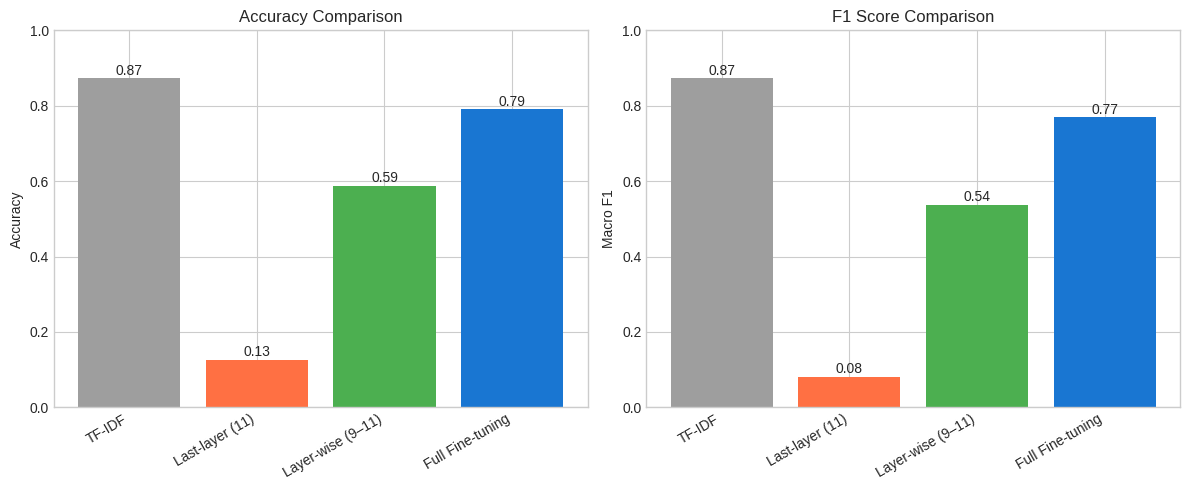

In [34]:
print("Model comparison visualization")

plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

models = results_table['Model']
accuracies = results_table['Accuracy']
f1_scores = results_table['Macro F1']

colors = ['#9E9E9E', '#FF7043', '#4CAF50', '#1976D2']

ax1.bar(range(len(models)), accuracies, color=colors)
ax1.set_xticks(range(len(models)))
ax1.set_xticklabels(models, rotation=30, ha='right')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_ylim([0, 1])

for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.2f}', ha='center')

ax2.bar(range(len(models)), f1_scores, color=colors)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, rotation=30, ha='right')
ax2.set_ylabel('Macro F1')
ax2.set_title('F1 Score Comparison')
ax2.set_ylim([0, 1])

for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.01, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

Efficiency vs performance plot


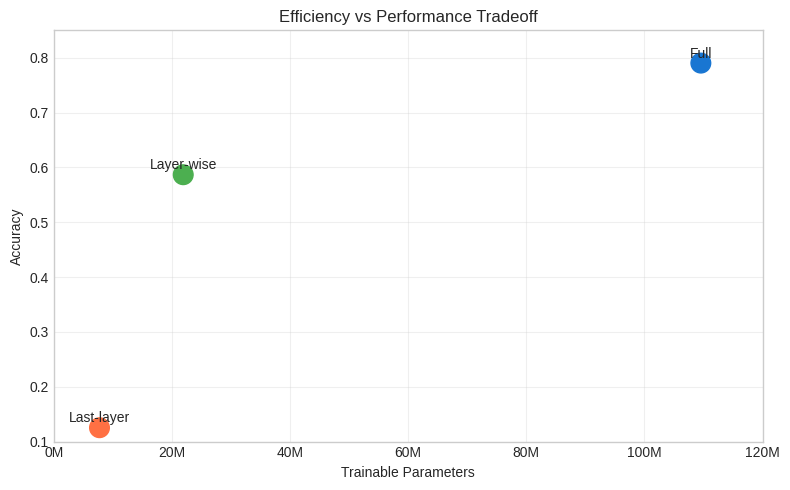

In [35]:
print("Efficiency vs performance plot")

fig, ax = plt.subplots(figsize=(8, 5))

bert_models = ['Last-layer', 'Layer-wise', 'Full']
bert_acc = [last['accuracy'], layerwise['accuracy'], full['accuracy']]
bert_params = [
    last['trainable_params'],
    layerwise['trainable_params'],
    full['trainable_params']
]

colors = ['#FF7043', '#4CAF50', '#1976D2']

ax.scatter(bert_params, bert_acc, s=200, c=colors)

for i, label in enumerate(bert_models):
    ax.text(bert_params[i], bert_acc[i] + 0.01, label, ha='center')

ax.set_xlabel('Trainable Parameters')
ax.set_ylabel('Accuracy')
ax.set_title('Efficiency vs Performance Tradeoff')

ax.set_ylim([0.1, 0.85])
ax.grid(alpha=0.3)

xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f'{int(x/1e6)}M' for x in xticks])

plt.tight_layout()
plt.savefig('cost_benefit_analysis.png', dpi=300)
plt.show()

Performance gap visualization


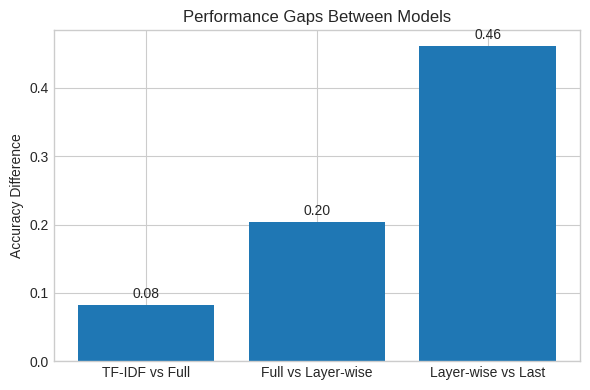

In [36]:
print("Performance gap visualization")

labels = ['TF-IDF vs Full', 'Full vs Layer-wise', 'Layer-wise vs Last']
values = [
    baseline['accuracy'] - full['accuracy'],
    full['accuracy'] - layerwise['accuracy'],
    layerwise['accuracy'] - last['accuracy']
]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.ylabel("Accuracy Difference")
plt.title("Performance Gaps Between Models")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("performance_gaps.png", dpi=300)
plt.show()

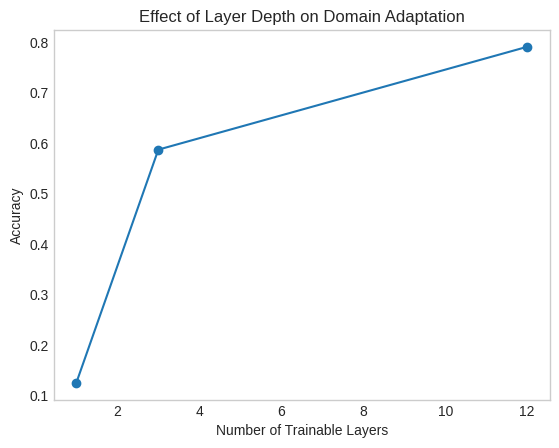

In [37]:
layers = [1, 3, 12]
accs = [last['accuracy'], layerwise['accuracy'], full['accuracy']]

plt.plot(layers, accs, marker='o')
plt.xlabel("Number of Trainable Layers")
plt.ylabel("Accuracy")
plt.title("Effect of Layer Depth on Domain Adaptation")
plt.grid()
plt.show()

In [39]:
print("FINAL RESULTS (CORRECTED STORY)")

with open('baseline_results.json') as f:
    baseline = json.load(f)
with open('baseline_bert_results.json') as f:
    baseline_bert = json.load(f)
with open('layerwise_results.json') as f:
    layerwise = json.load(f)
with open('full_results.json') as f:
    full = json.load(f)

results_df = pd.DataFrame([baseline, baseline_bert, layerwise, full])

print("FINAL RESULTS TABLE:")
print(results_df.to_string(index=False))

print("KEY FINDINGS")

print("\n IN-DOMAIN TRAINING IS BEST")
print(f"    • BERT in-domain: {baseline_bert['accuracy']:.1%}")
print(f"    • TF-IDF baseline: {baseline['accuracy']:.1%}")
print(f"    • Improvement: +{(baseline_bert['accuracy'] - baseline['accuracy'])*100:.1f} pp")
print(f"    ➜ Shows BERT's strength when trained on target domain")

print("\n TRANSFER LEARNING CAUSES NEGATIVE TRANSFER")
print(f"    • In-domain BERT: {baseline_bert['accuracy']:.1%}")
print(f"    • Full transfer: {full['accuracy']:.1%}")
print(f"    • Performance loss: {(baseline_bert['accuracy'] - full['accuracy'])*100:.1f} pp")
print(f"    ➜ Amazon domain knowledge INTERFERES with banking task")

print("\n LAYER-WISE TRANSFER INEFFICIENT")
print(f"    • Layer-wise: {layerwise['accuracy']:.1%}")
print(f"    • % of in-domain: {(layerwise['accuracy']/baseline_bert['accuracy'])*100:.1f}%")
print(f"    • % of full transfer: {(layerwise['accuracy']/full['accuracy'])*100:.1f}%")
print(f"    ➜ Neither efficient NOR effective for this domain pair")

print("\n DOMAIN SIMILARITY MATTERS")
print(f"    • Vocabulary overlap: 88.4%")
print(f"    • Semantic overlap: LOW (products vs. finance)")
print(f"    ➜ High lexical overlap masks semantic divergence")


results_df.to_csv('final_results.csv', index=False)
print("Saved: final_results.csv\n")

FINAL RESULTS (CORRECTED STORY)
FINAL RESULTS TABLE:
                    model  accuracy  macro_f1 trainable_params
          TF-IDF Baseline  0.872403  0.872637              N/A
BERT Baseline (In-domain)  0.921753  0.921825        109541453
        Layer-wise (9-11)  0.586688  0.537916         21913421
         Full Fine-tuning  0.790260  0.769322        109541453
KEY FINDINGS

 IN-DOMAIN TRAINING IS BEST
    • BERT in-domain: 92.2%
    • TF-IDF baseline: 87.2%
    • Improvement: +4.9 pp
    ➜ Shows BERT's strength when trained on target domain

 TRANSFER LEARNING CAUSES NEGATIVE TRANSFER
    • In-domain BERT: 92.2%
    • Full transfer: 79.0%
    • Performance loss: 13.1 pp
    ➜ Amazon domain knowledge INTERFERES with banking task

 LAYER-WISE TRANSFER INEFFICIENT
    • Layer-wise: 58.7%
    • % of in-domain: 63.6%
    • % of full transfer: 74.2%
    ➜ Neither efficient NOR effective for this domain pair

 DOMAIN SIMILARITY MATTERS
    • Vocabulary overlap: 88.4%
    • Semantic overl